# Low-Review Prediction: Candidate Problem Exploration

## Abstract

This notebook evaluates **low-rating classification** as a candidate analytics problem: identifying orders at risk of receiving a latest review score of one or two so that Olist can prioritise customer-experience intervention. The modelling population contains reviewed orders with at least one recorded item, ensuring that product, seller and basket predictors can be constructed. Low ratings account for 14.2% of 97,917 eligible orders. Numerical features are screened using Spearman correlation; categorical features are assessed using Cramér's V, group-level rates and focused hypothesis tests.

Days late is the strongest numerical feature (ρ = 0.374), and orders delivered more than seven days late are 8.7 times as likely to receive a low rating as those delivered more than seven days early *(Dashboard Figure 10).* Multi-item and multi-seller status are the strongest categorical indicators, with respectively 2.2 and 3.4 times the low-rating risk of their reference groups *(Dashboard Figure 11).* However, these complexity indicators have limited coverage: even the broader multi-item group identifies only 19.3% of low-rated orders.

Overall, low-rating prediction is a weaker standalone candidate. Its strongest relationship overlaps with the late-delivery problem, while individual non-delivery features provide limited signal or coverage. Other plausible drivers—including product quality, incorrect items, packaging and customer-service interactions—are unavailable as structured predictors; review comments occur with the outcome and would create leakage. Feature availability must therefore match the intended intervention point. These results are associative rather than causal, and a time-based modelling evaluation would still be required to establish out-of-sample precision, recall, calibration and lift.

## 1. Target and analytical unit

This section creates the outcome used throughout the notebook.

- **Unit of analysis:** one order.
- **Target:** `low_rating = 1` for a latest review score of 1–2; otherwise `0` for a score of 3–5.
- **Duplicate handling:** retain the latest review per order using review creation time, answer time and review ID as deterministic tie-breakers.
- **Population:** reviewed orders with at least one item record. Orders without reviews have no observable target; orders without items lack the product, seller and basket predictors required by this candidate.
- **Leakage control:** exclude review text and timing as predictors of that same review.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.3f}".format)
DATA_DIR = Path("data") if Path("data").exists() else Path.cwd().parent / "data"
BLUE, ORANGE = "#003D7C", "#EF7C00"

orders = pd.read_csv(
    DATA_DIR / "olist_orders_dataset.csv",
    parse_dates=["order_purchase_timestamp", "order_approved_at",
                 "order_delivered_carrier_date", "order_delivered_customer_date",
                 "order_estimated_delivery_date"],
)
reviews = pd.read_csv(
    DATA_DIR / "olist_order_reviews_dataset.csv",
    parse_dates=["review_creation_date", "review_answer_timestamp"],
)
customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")
products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")
sellers = pd.read_csv(DATA_DIR / "olist_sellers_dataset.csv")
payments = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")
translations = pd.read_csv(DATA_DIR / "product_category_name_translation.csv")
geolocation = pd.read_csv(DATA_DIR / "olist_geolocation_dataset.csv")

assert orders["order_id"].is_unique and customers["customer_id"].is_unique
assert products["product_id"].is_unique and sellers["seller_id"].is_unique
assert not items.duplicated(["order_id", "order_item_id"]).any()
assert orders["customer_id"].isin(customers["customer_id"]).all()
assert items["order_id"].isin(orders["order_id"]).all()
assert items["product_id"].isin(products["product_id"]).all()
assert items["seller_id"].isin(sellers["seller_id"]).all()


,orders,order_share_pct
review_score,,
1,10827,11.057
2,3067,3.132
3,8080,8.252
4,19012,19.416
5,56931,58.142


Reviewed orders: 97,917
Low-rating orders: 13,894 (14.19%)


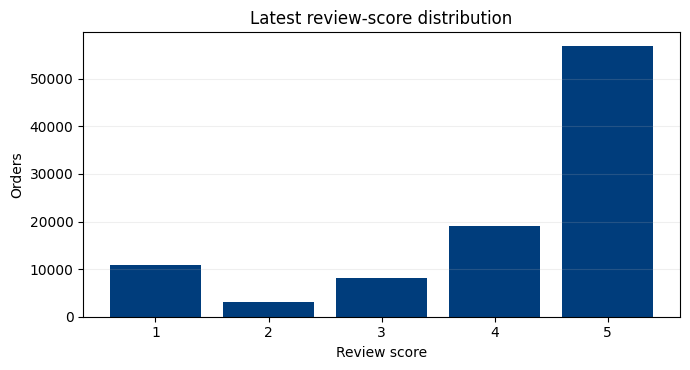

In [2]:
latest_reviews = (
    reviews.sort_values(["order_id", "review_creation_date", "review_answer_timestamp", "review_id"])
    .drop_duplicates("order_id", keep="last")
)
assert latest_reviews["order_id"].is_unique
assert latest_reviews["review_score"].between(1, 5).all()

orders_with_items = items[["order_id"]].drop_duplicates()
order_base = (
    orders.merge(customers, on="customer_id", validate="one_to_one")
    .merge(orders_with_items, on="order_id", how="inner", validate="one_to_one")
    .merge(latest_reviews[["order_id", "review_score"]], on="order_id", how="inner", validate="one_to_one")
)
order_base["low_rating"] = order_base["review_score"].le(2).astype(int)
target_summary = order_base.groupby("review_score").agg(orders=("order_id", "size"))
target_summary["order_share_pct"] = target_summary["orders"] / len(order_base) * 100
display(target_summary)
print(f"Reviewed orders: {len(order_base):,}")
print(f"Low-rating orders: {order_base['low_rating'].sum():,} ({order_base['low_rating'].mean():.2%})")

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.bar(target_summary.index.astype(str), target_summary["orders"], color=BLUE)
ax.set(title="Latest review-score distribution", xlabel="Review score", ylabel="Orders", ylim=(0, None))
ax.grid(axis="y", alpha=.2)
plt.tight_layout()
plt.show()


## 2. Order-level feature construction

This section converts the source tables into candidate predictors at the order level.

- Aggregate basket, product, seller, customer, payment and purchase-time information to **one row per order**.
- Derive order-complexity measures such as item, product, category and seller counts.
- Calculate customer–seller distance from ZIP-prefix centroids, avoiding row multiplication from repeated geolocation observations.
- Calculate seller history from reviews in earlier calendar months only, preventing the current or future reviews from entering a predictor.
- Treat product value as excluding freight; retain freight as separate features.

In [3]:
product_lookup = (
    products.merge(translations, on="product_category_name", how="left", validate="many_to_one")
    .assign(category=lambda x: x["product_category_name_english"].fillna("Unknown"))
)
product_lookup["product_volume_cm3"] = (
    product_lookup["product_length_cm"] * product_lookup["product_height_cm"] * product_lookup["product_width_cm"]
)
item_detail = (
    items.merge(product_lookup[["product_id", "category", "product_weight_g", "product_volume_cm3"]],
                on="product_id", validate="many_to_one")
    .merge(sellers[["seller_id", "seller_zip_code_prefix", "seller_state"]],
           on="seller_id", validate="many_to_one")
    .merge(order_base[["order_id", "customer_zip_code_prefix", "customer_state"]],
           on="order_id", validate="many_to_one")
)
item_detail["same_state"] = item_detail["customer_state"].eq(item_detail["seller_state"])
item_detail["unknown_category"] = item_detail["category"].eq("Unknown")
item_detail["basket_total_component"] = item_detail["price"] + item_detail["freight_value"]

geo_centroids = geolocation.groupby("geolocation_zip_code_prefix", as_index=False).agg(
    latitude=("geolocation_lat", "mean"), longitude=("geolocation_lng", "mean")
)
customer_geo = geo_centroids.rename(columns={
    "geolocation_zip_code_prefix": "customer_zip_code_prefix",
    "latitude": "customer_lat", "longitude": "customer_lng",
})
seller_geo = geo_centroids.rename(columns={
    "geolocation_zip_code_prefix": "seller_zip_code_prefix",
    "latitude": "seller_lat", "longitude": "seller_lng",
})
item_detail = item_detail.merge(customer_geo, on="customer_zip_code_prefix", how="left", validate="many_to_one")
item_detail = item_detail.merge(seller_geo, on="seller_zip_code_prefix", how="left", validate="many_to_one")
lat1, lon1 = np.radians(item_detail["customer_lat"]), np.radians(item_detail["customer_lng"])
lat2, lon2 = np.radians(item_detail["seller_lat"]), np.radians(item_detail["seller_lng"])
dlat, dlon = lat2-lat1, lon2-lon1
a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
item_detail["distance_km"] = 6371 * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a.clip(upper=1)))

item_features = item_detail.groupby("order_id").agg(
    item_count=("order_item_id", "size"),
    product_count=("product_id", "nunique"),
    seller_count=("seller_id", "nunique"),
    category_count=("category", "nunique"),
    product_value=("price", "sum"),
    freight_value=("freight_value", "sum"),
    basket_total=("basket_total_component", "sum"),
    mean_product_weight_g=("product_weight_g", "mean"),
    total_product_volume_cm3=("product_volume_cm3", "sum"),
    mean_seller_distance_km=("distance_km", "mean"),
    same_state_item_share=("same_state", "mean"),
    unknown_category_share=("unknown_category", "mean"),
)
item_features["freight_share"] = item_features["freight_value"] / item_features["basket_total"].replace(0, np.nan)
dominant_category = (
    item_detail.groupby(["order_id", "category"], as_index=False)["price"].sum()
    .sort_values(["order_id", "price", "category"], ascending=[True, False, True])
    .drop_duplicates("order_id").set_index("order_id")["category"].rename("dominant_category")
)

payment_features = payments.groupby("order_id").agg(
    payment_value=("payment_value", "sum"),
    maximum_installments=("payment_installments", "max"),
    payment_record_count=("payment_sequential", "size"),
    payment_type_count=("payment_type", "nunique"),
)
primary_payment = (
    payments.sort_values(["order_id", "payment_value", "payment_type"], ascending=[True, False, True])
    .drop_duplicates("order_id").set_index("order_id")["payment_type"].rename("primary_payment_type")
)


In [4]:
# Seller history through the end of the month before each purchase.
order_sellers = item_detail[["order_id", "seller_id"]].drop_duplicates().merge(
    orders[["order_id", "order_purchase_timestamp"]], on="order_id", validate="many_to_one"
)
reviewed_seller_events = order_sellers.merge(
    latest_reviews[["order_id", "review_score", "review_creation_date"]],
    on="order_id", how="inner", validate="many_to_one",
)
reviewed_seller_events["month"] = reviewed_seller_events["review_creation_date"].dt.to_period("M")
reviewed_seller_events["low"] = reviewed_seller_events["review_score"].le(2).astype(int)
seller_month = reviewed_seller_events.groupby(["seller_id", "month"]).agg(
    reviews=("order_id", "nunique"), low_reviews=("low", "sum")
)
months = pd.period_range(
    min(orders["order_purchase_timestamp"].min(), reviews["review_creation_date"].min()).to_period("M"),
    max(orders["order_purchase_timestamp"].max(), reviews["review_creation_date"].max()).to_period("M"),
    freq="M",
)
seller_month = (
    seller_month.reindex(pd.MultiIndex.from_product(
        [sellers["seller_id"].unique(), months], names=["seller_id", "month"]
    ), fill_value=0).reset_index().sort_values(["seller_id", "month"])
)
seller_month["prior_review_count"] = (
    seller_month.groupby("seller_id")["reviews"].cumsum() - seller_month["reviews"]
)
seller_month["prior_low_count"] = (
    seller_month.groupby("seller_id")["low_reviews"].cumsum() - seller_month["low_reviews"]
)

order_sellers["month"] = order_sellers["order_purchase_timestamp"].dt.to_period("M")
order_seller_history = order_sellers.merge(
    seller_month[["seller_id", "month", "prior_review_count", "prior_low_count"]],
    on=["seller_id", "month"], how="left", validate="many_to_one",
)
seller_history = order_seller_history.groupby("order_id").agg(
    seller_prior_review_count=("prior_review_count", "sum"),
    seller_prior_low_count=("prior_low_count", "sum"),
)
seller_history["seller_prior_low_rate"] = (
    seller_history["seller_prior_low_count"] /
    seller_history["seller_prior_review_count"].replace(0, np.nan)
)


In [5]:
analysis = (
    order_base.set_index("order_id")
    .join([item_features, dominant_category, payment_features, primary_payment, seller_history],
          how="left", validate="one_to_one")
)
analysis["purchase_hour"] = analysis["order_purchase_timestamp"].dt.hour
analysis["purchase_weekday"] = analysis["order_purchase_timestamp"].dt.day_name()
analysis["purchase_month"] = analysis["order_purchase_timestamp"].dt.month
analysis["purchase_weekend"] = analysis["order_purchase_timestamp"].dt.dayofweek.ge(5).astype(int)
analysis["customer_prior_purchase_occasions"] = (
    analysis.groupby("customer_unique_id")["order_purchase_timestamp"]
    .rank(method="dense").sub(1)
)
analysis["approval_hours"] = (
    analysis["order_approved_at"] - analysis["order_purchase_timestamp"]
).dt.total_seconds()/3600
analysis["promised_days"] = (
    analysis["order_estimated_delivery_date"] - analysis["order_purchase_timestamp"]
).dt.total_seconds()/86400
analysis["carrier_handoff_days"] = (
    analysis["order_delivered_carrier_date"] - analysis["order_approved_at"]
).dt.total_seconds()/86400
analysis["delivery_days"] = (
    analysis["order_delivered_customer_date"] - analysis["order_purchase_timestamp"]
).dt.total_seconds()/86400
analysis["carrier_to_customer_days"] = (
    analysis["order_delivered_customer_date"] - analysis["order_delivered_carrier_date"]
).dt.total_seconds()/86400
analysis["days_vs_estimate"] = (
    analysis["order_delivered_customer_date"] - analysis["order_estimated_delivery_date"]
).dt.total_seconds()/86400
analysis["days_late"] = analysis["days_vs_estimate"].clip(lower=0)
analysis["late_delivery"] = analysis["days_vs_estimate"].gt(0).astype(float).where(
    analysis["days_vs_estimate"].notna()
)
analysis["multi_item"] = analysis["item_count"].gt(1).astype(float).where(analysis["item_count"].notna())
analysis["multi_seller"] = analysis["seller_count"].gt(1).astype(float).where(analysis["seller_count"].notna())
assert analysis.index.is_unique and analysis["low_rating"].notna().all()
display(analysis.isna().mean().mul(100).sort_values(ascending=False).head(20).rename("Missing (%)").to_frame())
print(f"Analysis table: {len(analysis):,} reviewed orders.")


,Missing (%)
seller_prior_low_rate,9.424
carrier_to_customer_days,2.132
late_delivery,2.131
days_vs_estimate,2.131
days_late,2.131
delivery_days,2.131
order_delivered_customer_date,2.131
carrier_handoff_days,1.026
order_delivered_carrier_date,1.012
mean_seller_distance_km,0.497


Analysis table: 97,917 reviewed orders.


## 3. Feature availability and leakage controls

A deployable model may use only information known when its prediction is made.

- The table separates early order information from later delivery outcomes.
- Review score and text are outcomes, not predictors of the same review.
- Exact availability of payment and estimated-delivery fields is undocumented and would require operational verification.

| Decision point | Candidate information | Purpose |
|---|---|---|
| Around approval | Basket value and composition, customer and seller locations, payment summary, purchase timing, estimated delivery window, prior seller reviews | Early risk assessment |
| At carrier handoff | Approval-to-handoff duration | Escalation while the order is in transit |
| At delivery | Actual delivery duration and performance against the estimate | Customer-service recovery |
| After review | Review score and text | Outcome analysis only; invalid as predictors of that review |

Final order status is also excluded because it describes a later lifecycle outcome.

## 4. Numerical feature screening

This section asks which numerical features have the strongest monotonic relationships with low ratings.

- **Method:** Spearman correlation, which is suitable for skewed variables and does not assume a linear relationship.
- **Main result:** delivery outcomes dominate; `days_late` is strongest at ρ = 0.374.
- **Non-delivery result:** the largest correlation is `item_count` at only ρ = 0.129.
- **Interpretation:** a small correlation rules out only a strong global monotonic relationship; it does not eliminate thresholds, rare-group effects or interactions.
- Each coefficient uses complete feature–target pairs and measures association, not predictive performance or causation.

,Feature,Available,Orders,Low ratings,Missing (%),Spearman rho
27,days_late,At delivery,95830,12276,2.131,0.374
28,late_delivery,At delivery,95830,12276,2.131,0.364
24,delivery_days,At delivery,95830,12276,2.131,0.215
26,days_vs_estimate,At delivery,95830,12276,2.131,0.181
25,carrier_to_customer_days,At delivery,95829,12276,2.132,0.178
4,item_count,Around approval,97917,13894,0.000,0.129
6,seller_count,Around approval,97917,13894,0.000,0.109
5,product_count,Around approval,97917,13894,0.000,0.106
23,carrier_handoff_days,At carrier handoff,96912,13041,1.026,0.096
1,freight_value,Around approval,97917,13894,0.000,0.090


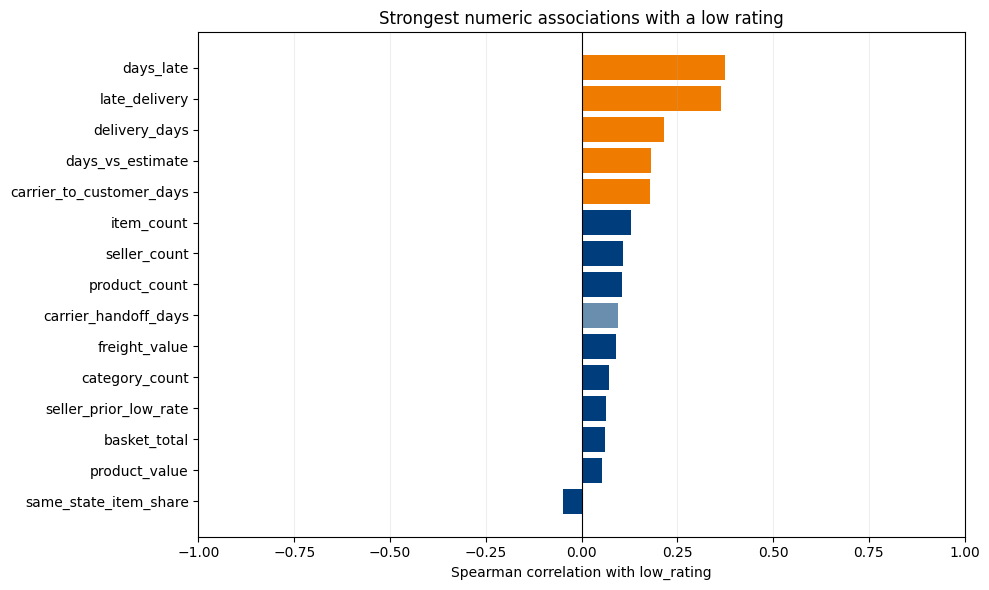

In [6]:
feature_stage = {
    "product_value": "Around approval", "freight_value": "Around approval",
    "basket_total": "Around approval", "freight_share": "Around approval",
    "item_count": "Around approval", "product_count": "Around approval",
    "seller_count": "Around approval", "category_count": "Around approval",
    "mean_product_weight_g": "Around approval", "total_product_volume_cm3": "Around approval",
    "mean_seller_distance_km": "Around approval", "same_state_item_share": "Around approval",
    "maximum_installments": "Around approval", "payment_record_count": "Around approval",
    "payment_type_count": "Around approval", "purchase_hour": "Around approval",
    "purchase_month": "Around approval", "purchase_weekend": "Around approval",
    "approval_hours": "Around approval", "promised_days": "Around approval",
    "seller_prior_review_count": "Around approval", "seller_prior_low_rate": "Around approval",
    "customer_prior_purchase_occasions": "Around approval",
    "carrier_handoff_days": "At carrier handoff",
    "delivery_days": "At delivery", "carrier_to_customer_days": "At delivery",
    "days_vs_estimate": "At delivery", "days_late": "At delivery",
    "late_delivery": "At delivery",
}
association_rows = []
for feature, stage in feature_stage.items():
    pairs = analysis[[feature, "low_rating"]].dropna().astype(float)
    rho = pairs.rank().corr().iloc[0,1] if pairs[feature].nunique()>1 else np.nan
    association_rows.append({
        "Feature": feature, "Available": stage, "Orders": len(pairs),
        "Low ratings": int(pairs["low_rating"].sum()),
        "Missing (%)": analysis[feature].isna().mean()*100,
        "Spearman rho": rho,
    })
numeric_associations = pd.DataFrame(association_rows)
numeric_associations["absolute_rho"] = numeric_associations["Spearman rho"].abs()
numeric_associations = numeric_associations.sort_values("absolute_rho", ascending=False)
display(numeric_associations.drop(columns="absolute_rho").head(15))

plot_data = numeric_associations.nlargest(15, "absolute_rho").sort_values("Spearman rho")
colors = plot_data["Available"].map({
    "Around approval": BLUE, "At carrier handoff": "#6A8EAE", "At delivery": ORANGE
})
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_data["Feature"], plot_data["Spearman rho"], color=colors)
ax.axvline(0, color="black", linewidth=.8)
ax.set(title="Strongest numeric associations with a low rating",
       xlabel="Spearman correlation with low_rating", xlim=(-1,1))
ax.grid(axis="x", alpha=.2)
plt.tight_layout()
plt.show()


## 5. Categorical screening and group comparisons

This section identifies whether particular groups experience materially different low-rating rates.

- **Overall association:** Cramér's V summarises the relationship between each categorical feature and the binary target.
- **Group interpretation:** low-rating rates show the direction and practical size of differences; sample sizes and 95% Wilson intervals show their precision.
- **Main result:** multi-item and multi-seller status are the strongest categorical indicators, whereas category and state are weaker and payment method is negligible.
- Displayed category and state groups require at least 500 reviewed orders; payment groups require at least 50.

,Feature,Orders,Groups,Cramer's V
4,multi_item,97917,2,0.128
5,multi_seller,97917,2,0.109
2,customer_state,97917,27,0.089
0,dominant_category,97917,72,0.067
3,purchase_weekday,97917,7,0.014
1,primary_payment_type,97916,4,0.008


,orders,low_ratings,low_rating_rate_pct,lower_pct,upper_pct
multi_item,,,,,
Single item,88227,11213.000,12.709,12.491,12.931
Multiple items,9690,2681.000,27.668,26.786,28.567


,orders,low_ratings,low_rating_rate_pct,lower_pct,upper_pct
multi_seller,,,,,
Single seller,96653,13296.000,13.756,13.541,13.975
Multiple sellers,1264,598.000,47.310,44.570,50.067


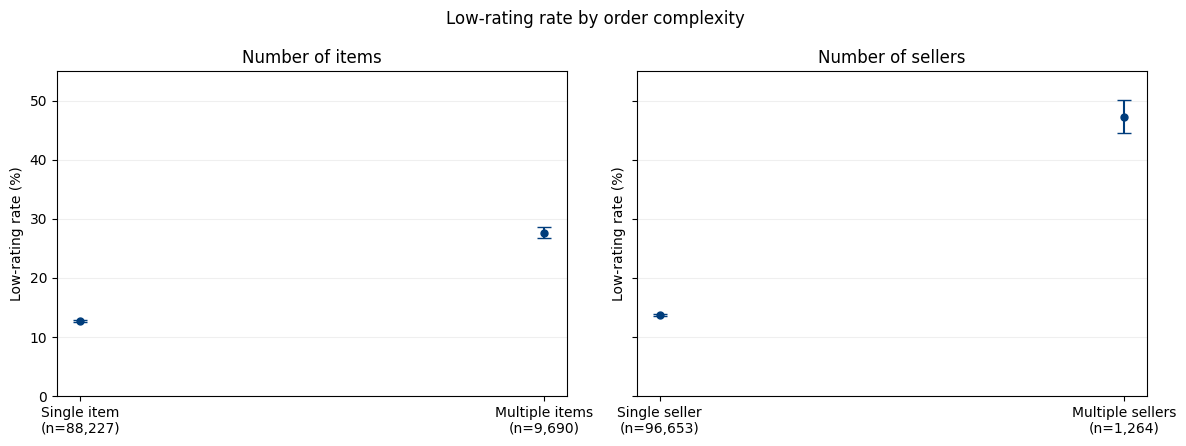

Secondary group comparisons: lowest and highest category/state rates


,orders,low_ratings,low_rating_rate_pct,lower_pct,upper_pct
dominant_category,,,,,
books_general_interest,505,41.000,8.119,6.041,10.829
luggage_accessories,1025,94.000,9.171,7.553,11.093
stationery,2274,253.000,11.126,9.898,12.484
pet_shop,1692,193.000,11.407,9.979,13.010
furniture_decor,6281,1018.000,16.208,15.317,17.140
bed_bath_table,9245,1535.000,16.604,15.859,17.376
Unknown,1431,279.000,19.497,17.527,21.630
office_furniture,1260,285.000,22.619,20.394,25.010


,orders,low_ratings,low_rating_rate_pct,lower_pct,upper_pct
primary_payment_type,,,,,
credit_card,73907,10546.000,14.269,14.019,14.523
boleto,19471,2701.000,13.872,13.394,14.365
voucher,3024,453.000,14.980,13.753,16.297
debit_card,1514,193.000,12.748,11.161,14.522


,orders,low_ratings,low_rating_rate_pct,lower_pct,upper_pct
customer_state,,,,,
PR,4972,592.000,11.907,11.036,12.836
SP,41109,4956.000,12.056,11.745,12.374
MG,11466,1464.000,12.768,12.170,13.392
RS,5412,703.000,12.990,12.120,13.912
CE,1317,253.000,19.210,17.173,21.426
PA,957,185.000,19.331,16.954,21.954
RJ,12598,2551.000,20.249,19.557,20.960
MA,735,159.000,21.633,18.808,24.753


In [7]:
def rate_summary(frame, group, target="low_rating"):
    result = frame.groupby(group, observed=True)[target].agg(orders="size", low_ratings="sum")
    n, p, z = result["orders"].astype(float), result["low_ratings"]/result["orders"], 1.96
    centre = (p + z*z/(2*n))/(1+z*z/n)
    half = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n))/(1+z*z/n)
    result["low_rating_rate_pct"] = 100*p
    result["lower_pct"], result["upper_pct"] = 100*(centre-half), 100*(centre+half)
    return result

def cramers_v(frame, feature, target="low_rating"):
    table = pd.crosstab(frame[feature], frame[target])
    observed = table.to_numpy(dtype=float)
    expected = np.outer(observed.sum(axis=1), observed.sum(axis=0))/observed.sum()
    chi2 = np.divide((observed-expected)**2, expected, out=np.zeros_like(expected), where=expected>0).sum()
    return np.sqrt(chi2/observed.sum()/max(1, min(observed.shape[0]-1, observed.shape[1]-1)))

categorical_features = ["dominant_category", "primary_payment_type", "customer_state",
                        "purchase_weekday", "multi_item", "multi_seller"]
categorical_associations = pd.DataFrame([
    {"Feature": feature, "Orders": analysis[feature].notna().sum(),
     "Groups": analysis[feature].nunique(dropna=True), "Cramer's V": cramers_v(analysis.dropna(subset=[feature]), feature)}
    for feature in categorical_features
]).sort_values("Cramer's V", ascending=False)
display(categorical_associations)

multi_item_rates = rate_summary(analysis.dropna(subset=["multi_item"]), "multi_item").rename(
    index={0.0: "Single item", 1.0: "Multiple items"}
)
multi_seller_rates = rate_summary(analysis.dropna(subset=["multi_seller"]), "multi_seller").rename(
    index={0.0: "Single seller", 1.0: "Multiple sellers"}
)
display(multi_item_rates)
display(multi_seller_rates)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, summary, title in [
    (axes[0], multi_item_rates, "Number of items"),
    (axes[1], multi_seller_rates, "Number of sellers"),
]:
    positions = np.arange(len(summary))
    ax.errorbar(positions, summary["low_rating_rate_pct"], yerr=[
        summary["low_rating_rate_pct"]-summary["lower_pct"],
        summary["upper_pct"]-summary["low_rating_rate_pct"],
    ], fmt="o", markersize=5, color=BLUE, capsize=5)
    ax.set_xticks(positions, [f"{name}\n(n={n:,})" for name,n in zip(summary.index,summary["orders"])])
    ax.set(title=title, ylabel="Low-rating rate (%)", ylim=(0,55))
    ax.grid(axis="y", alpha=.2)
fig.suptitle("Low-rating rate by order complexity")
plt.tight_layout()
plt.show()

def compact_extremes(summary, groups=4):
    ordered = summary.sort_values("low_rating_rate_pct")
    return pd.concat([ordered.head(groups), ordered.tail(groups)]).drop_duplicates()

category_rates = rate_summary(analysis, "dominant_category")
category_rates = category_rates.loc[category_rates["orders"].ge(500)]
payment_rates = rate_summary(analysis, "primary_payment_type")
payment_rates = payment_rates.loc[payment_rates["orders"].ge(50)].sort_values("orders", ascending=False)
state_rates = rate_summary(analysis, "customer_state")
state_rates = state_rates.loc[state_rates["orders"].ge(500)]
print("Secondary group comparisons: lowest and highest category/state rates")
display(compact_extremes(category_rates))
display(payment_rates)
display(compact_extremes(state_rates))


### 5.1 Focused inference for order complexity

The two most notable categorical indicators receive a focused statistical check.

- Chi-square tests assess whether low-rating status is independent of item and seller complexity.
- Risk ratios and 95% confidence intervals quantify association size and uncertainty.
- Both differences are statistically significant (`p < 0.001`): multi-item risk is 2.2 times the single-item risk, and multi-seller risk is 3.4 times the single-seller risk.
- Significance does not imply causation or strong population-wide prediction; the higher-complexity groups are uncommon.

In [8]:
from scipy.stats import chi2_contingency

def complexity_test(frame, feature, label):
    sample = frame.dropna(subset=[feature]).copy()
    exposed = sample[feature].eq(1)
    a = int(sample.loc[exposed, "low_rating"].sum())
    b = int(exposed.sum() - a)
    c = int(sample.loc[~exposed, "low_rating"].sum())
    d = int((~exposed).sum() - c)
    chi2, p_value, _, _ = chi2_contingency([[a, b], [c, d]], correction=False)
    exposed_rate, reference_rate = a / (a + b), c / (c + d)
    risk_ratio = exposed_rate / reference_rate
    log_rr_se = np.sqrt(1/a - 1/(a+b) + 1/c - 1/(c+d))
    return {
        "Feature": label,
        "Higher-complexity rate (%)": exposed_rate * 100,
        "Reference rate (%)": reference_rate * 100,
        "Difference (pp)": (exposed_rate-reference_rate) * 100,
        "Risk ratio": risk_ratio,
        "RR 95% CI lower": np.exp(np.log(risk_ratio)-1.96*log_rr_se),
        "RR 95% CI upper": np.exp(np.log(risk_ratio)+1.96*log_rr_se),
        "Chi-square": chi2,
        "p-value": "<0.001" if p_value < 0.001 else f"{p_value:.3f}",
    }

complexity_tests = pd.DataFrame([
    complexity_test(analysis, "multi_item", "Multiple vs single item"),
    complexity_test(analysis, "multi_seller", "Multiple vs single seller"),
])
display(complexity_tests)


,Feature,Higher-complexity rate (%),Reference rate (%),Difference (pp),Risk ratio,RR 95% CI lower,RR 95% CI upper,Chi-square,p-value
0,Multiple vs single item,27.668,12.709,14.958,2.177,2.099,2.258,1604.465,<0.001
1,Multiple vs single seller,47.310,13.756,33.554,3.439,3.238,3.653,1153.655,<0.001


## 6. Delivery-performance relationships

This section examines how low-rating rates change with delivery duration and performance against the estimated date.

- Restrict analysis to reviewed orders with valid actual and estimated delivery timestamps.
- Compare ordered timing and duration bands using group rates and 95% Wilson intervals.
- **Main result:** low-rating risk increases sharply with lateness; orders more than seven days late have 8.7 times the risk of orders more than seven days early.
- These variables are known only at delivery and substantially overlap with the late-delivery candidate.

,orders,low_ratings,low_rating_rate_pct,lower_pct,upper_pct
delivery_timing_band,,,,,
More than 7 days early,70934,6369.000,8.979,8.771,9.191
0–7 days early,17234,1766.000,10.247,9.803,10.709
1–3 days late,2636,504.000,19.120,17.664,20.666
4–7 days late,1773,1086.000,61.252,58.962,63.493
Over 7 days late,3253,2551.000,78.420,76.973,79.800


,orders,low_ratings,low_rating_rate_pct,lower_pct,upper_pct
delivery_duration_band,,,,,
Up to 7 days,25933,1931.000,7.446,7.133,7.772
7–14 days,40000,3586.000,8.965,8.689,9.249
14–21 days,17582,2054.000,11.682,11.216,12.166
Over 21 days,12315,4705.000,38.205,37.351,39.067


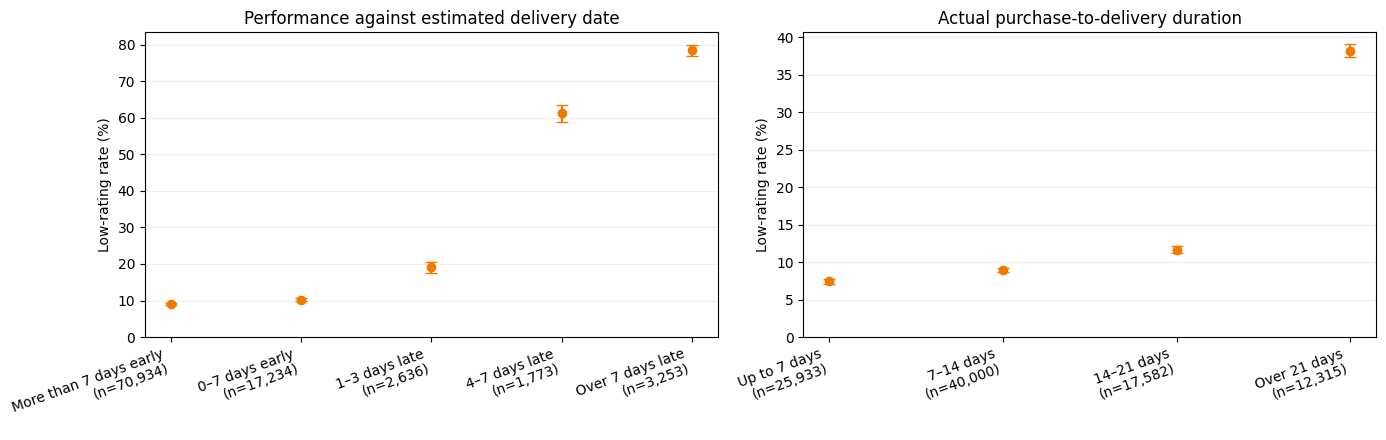

In [9]:
delivered = analysis.loc[
    analysis["order_delivered_customer_date"].notna()
    & analysis["order_estimated_delivery_date"].notna()
    & analysis["delivery_days"].ge(0)
].copy()
timing_order = ["More than 7 days early", "0–7 days early", "1–3 days late", "4–7 days late", "Over 7 days late"]
days = delivered["days_vs_estimate"]
delivered["delivery_timing_band"] = pd.Categorical(
    np.select([days.lt(-7), days.le(0), days.le(3), days.le(7)], timing_order[:-1], default=timing_order[-1]),
    categories=timing_order, ordered=True,
)
delivered["delivery_duration_band"] = pd.cut(
    delivered["delivery_days"], bins=[0, 7, 14, 21, np.inf],
    labels=["Up to 7 days", "7–14 days", "14–21 days", "Over 21 days"], include_lowest=True,
)
timing_rates = rate_summary(delivered, "delivery_timing_band")
duration_rates = rate_summary(delivered, "delivery_duration_band")
display(timing_rates)
display(duration_rates)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, summary, title in [
    (axes[0], timing_rates, "Performance against estimated delivery date"),
    (axes[1], duration_rates, "Actual purchase-to-delivery duration"),
]:
    positions = np.arange(len(summary))
    ax.errorbar(positions, summary["low_rating_rate_pct"], yerr=[
        summary["low_rating_rate_pct"]-summary["lower_pct"],
        summary["upper_pct"]-summary["low_rating_rate_pct"],
    ], fmt="o", color=ORANGE, capsize=4)
    ax.set_xticks(positions, [f"{name}\n(n={n:,})" for name,n in zip(summary.index,summary["orders"])],
                  rotation=20, ha="right")
    ax.set(title=title, ylabel="Low-rating rate (%)", ylim=(0,None))
    ax.grid(axis="y", alpha=.2)
plt.tight_layout()
plt.show()
